<a href="https://colab.research.google.com/github/lcuenca1/Data201/blob/main/Assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Part I

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [6]:
df = pd.read_csv("https://raw.githubusercontent.com/lcuenca1/Data201/refs/heads/main/Dataset/housing.csv")

In [7]:
df.columns

Index(['listing_id', 'price', 'size', 'bedrooms', 'neighborhood', 'type'], dtype='object')

A. *Scatterplot*

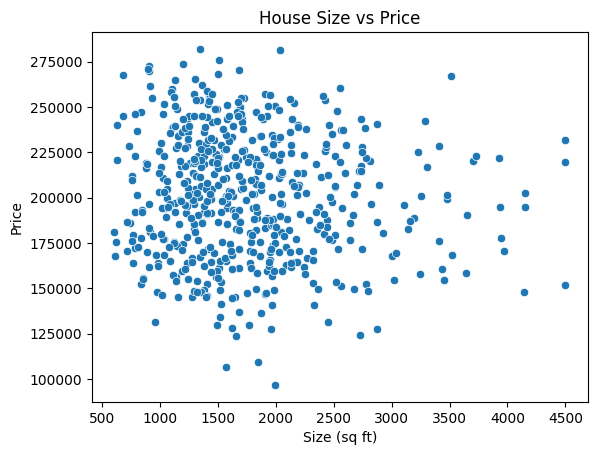

In [8]:
sns.scatterplot(x="size", y="price", data=df)

plt.xlabel("Size (sq ft)")
plt.ylabel("Price")
plt.title("House Size vs Price")

plt.show()


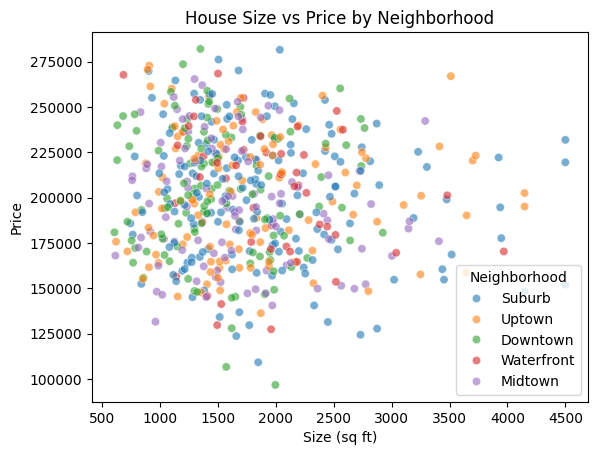

In [9]:
sns.scatterplot( x="size", y="price", hue="neighborhood", data=df, alpha=0.6)

plt.xlabel("Size (sq ft)")
plt.ylabel("Price")
plt.title("House Size vs Price by Neighborhood")
plt.legend(title="Neighborhood")
plt.show()

Seaborn handles colors, legends and the general aesthetics of the plot, which helps using less commands for more complex graphs. Transparency is useful because many houses overlap  at similar sizes and price, after that, now is possible to see where data is more dense and how is the pattern working, this improve readability and avoid confusions.

B. *Faceting*

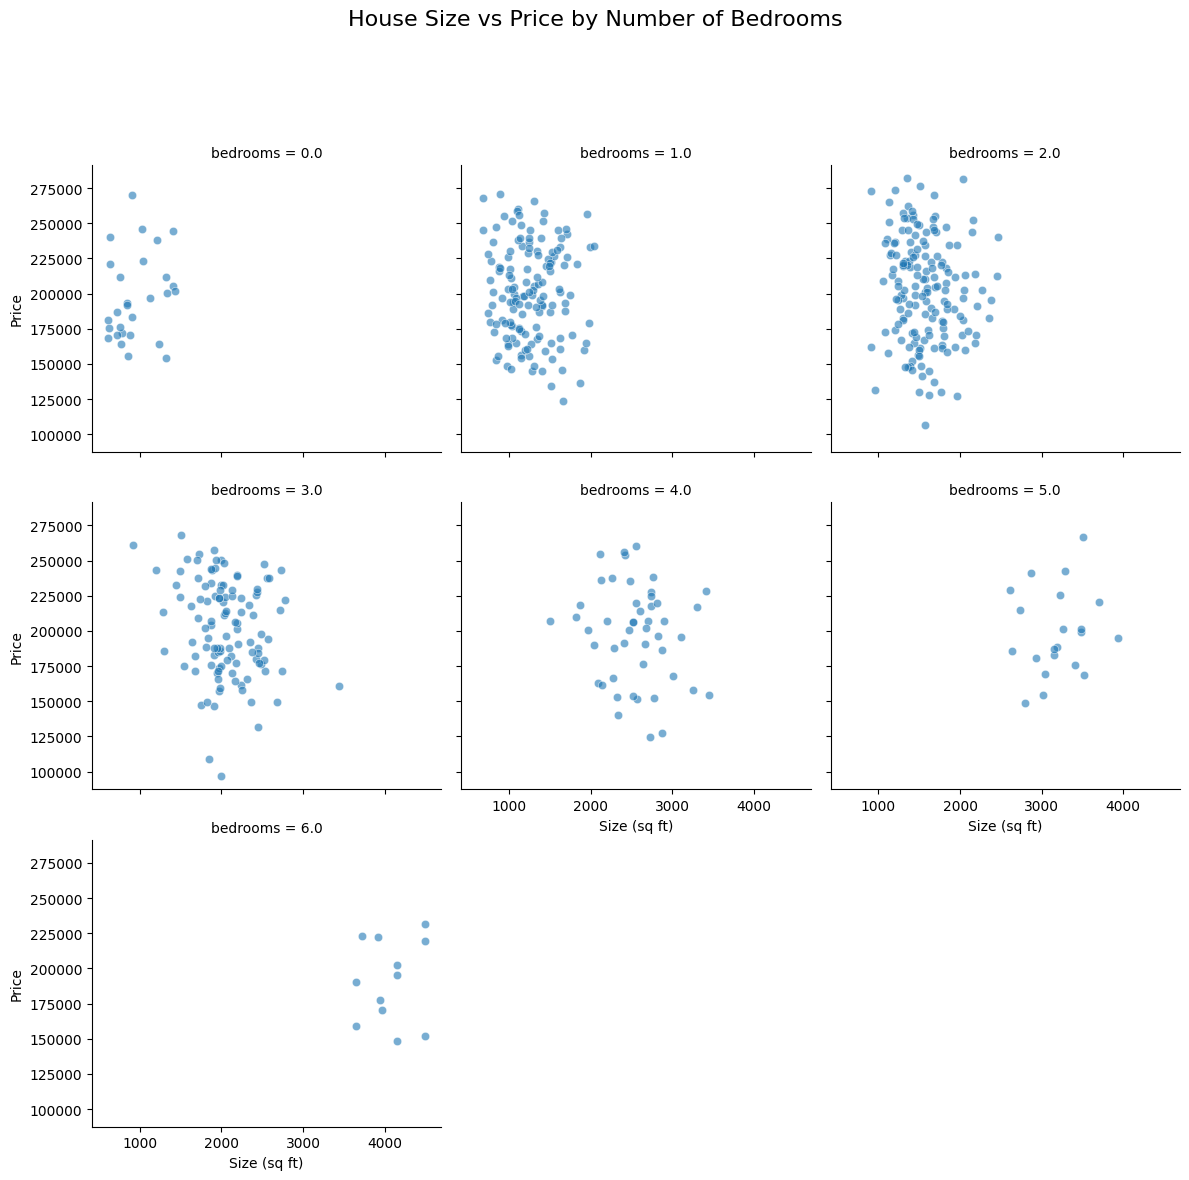

In [10]:
g = sns.FacetGrid(df, col="bedrooms", col_wrap=3, height=4, sharex=True, sharey=True)
g.map_dataframe(sns.scatterplot, x="size", y="price", alpha=0.6)

g.set_axis_labels("Size (sq ft)", "Price")
g.fig.suptitle("House Size vs Price by Number of Bedrooms", fontsize=16)
g.fig.subplots_adjust(top=0.85)  # Adjust space for the suptitle

plt.show()

For all bedrooms groups, price tends to increase as size increases, showing a positive relationship. However, the overall pattern between size and price looks similar accross bedrom categories. This suggest that size influences price most of the time, regardless of how many bedrooms each contain.

C. *Histogram*

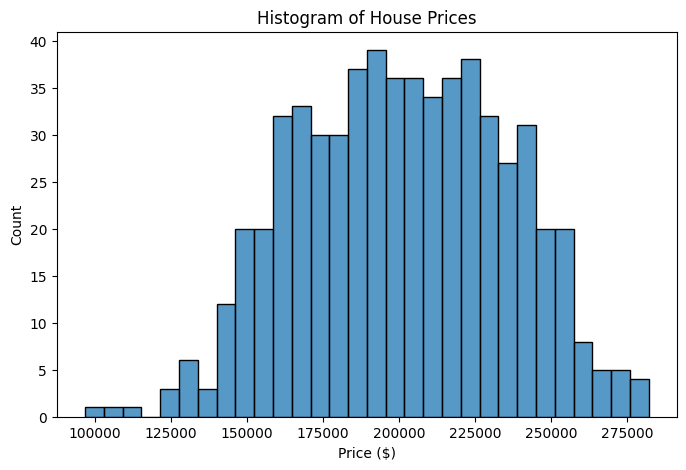

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=30, kde=False)

plt.xlabel("Price ($)")
plt.ylabel("Count")
plt.title("Histogram of House Prices")
plt.show()

*Density Plot of Price*

/tmp/ipykernel_319/3519896040.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df["price"], shade=True)


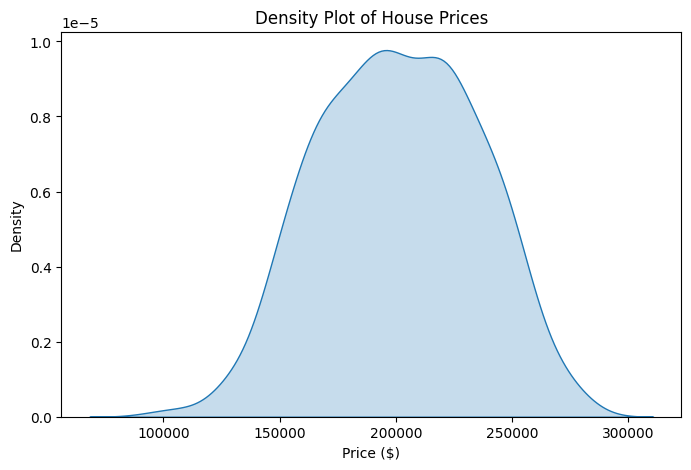

In [12]:
plt.figure(figsize=(8,5))
sns.kdeplot(df["price"], shade=True)

plt.xlabel("Price ($)")
plt.ylabel("Density")
plt.title("Density Plot of House Prices")
plt.show()

*Boxplot of Price*


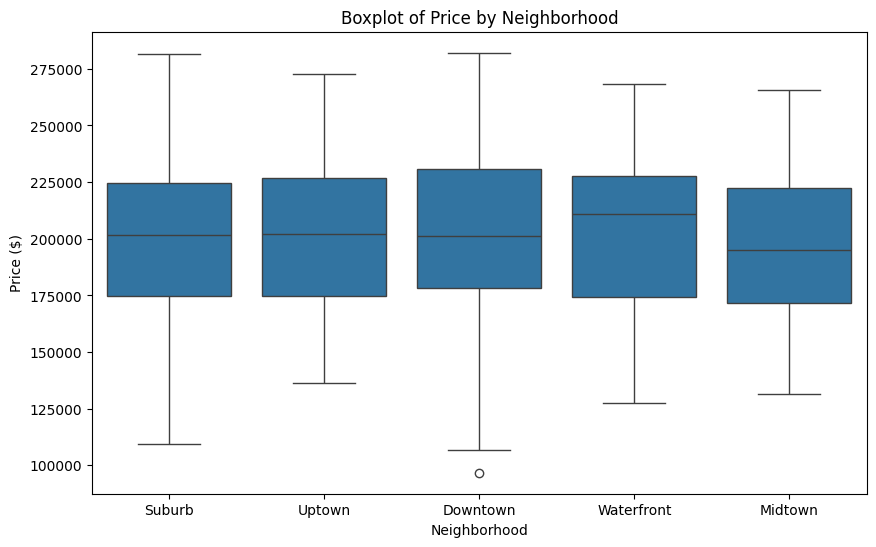

In [13]:
plt.figure(figsize=(10,6))
sns.boxplot(x="neighborhood", y="price", data=df)

plt.xlabel("Neighborhood")
plt.ylabel("Price ($)")
plt.title("Boxplot of Price by Neighborhood")
plt.show()

Neighborhoods do appear to differ in price. The boxplot shows that Waterfront  has the highest median price, while Midtown has the lowest median price. This difference suggest that homes in the neighborhood of Waterfront are generally more expensive compare to the other neighborhoods.This boxplot supports the idea that location influences housing prices.

## Part II = Linear Regression

*Multiple Regression*

In [15]:
import statsmodels.formula.api as smf

model = smf.ols('price ~ size + bedrooms + neighborhood', data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     1.460
Date:                Tue, 03 Mar 2026   Prob (F-statistic):              0.190
Time:                        16:38:59   Log-Likelihood:                -6212.8
No. Observations:                 524   AIC:                         1.244e+04
Df Residuals:                     517   BIC:                         1.247e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

The coefficient is size -10.93, which means that for every extra square foot of a house, the price goes down for about 511, if the number of bedrooms and neighborhood stay the same. the p-value is 0.010, meaning that is statistically significant. The R-square is very low, suggesting that most of the variation in price come from other factors that are not included in this model.

## Part III - Prediction

*Split the Data*

In [18]:
from sklearn.model_selection import train_test_split
import pandas as pd

X = pd.get_dummies(df[['size', 'bedrooms', 'neighborhood']], drop_first=True)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

*Fit Linear Regression and Compute*

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Drop missing values
X_train_clean = X_train.dropna()
y_train_clean = y_train.loc[X_train_clean.index]

X_test_clean = X_test.dropna()
y_test_clean = y_test.loc[X_test_clean.index]

model = LinearRegression()
model.fit(X_train_clean, y_train_clean)
y_pred = model.predict(X_test_clean)

print("RMSE:", np.sqrt(mean_squared_error(y_test_clean, y_pred)))
print("R²:", r2_score(y_test_clean, y_pred))

RMSE: 35422.822095707874
R²: -0.02286450358574621


Scikit-learn it is design for prediction, not for testing hypotheses, For understanding relationships between variables and explaining  how each affet the outcome, we use statsmodel. which provides coefficients, p-value, and confidence iterval. For predicting new data, scikit is needed. These re different goals because explanation is about interpreting relationships in the data, while predictions is about making the most accurate estimates of untouched data.

## Part IV - Integrated Thinking

<Figure size 1000x600 with 0 Axes>

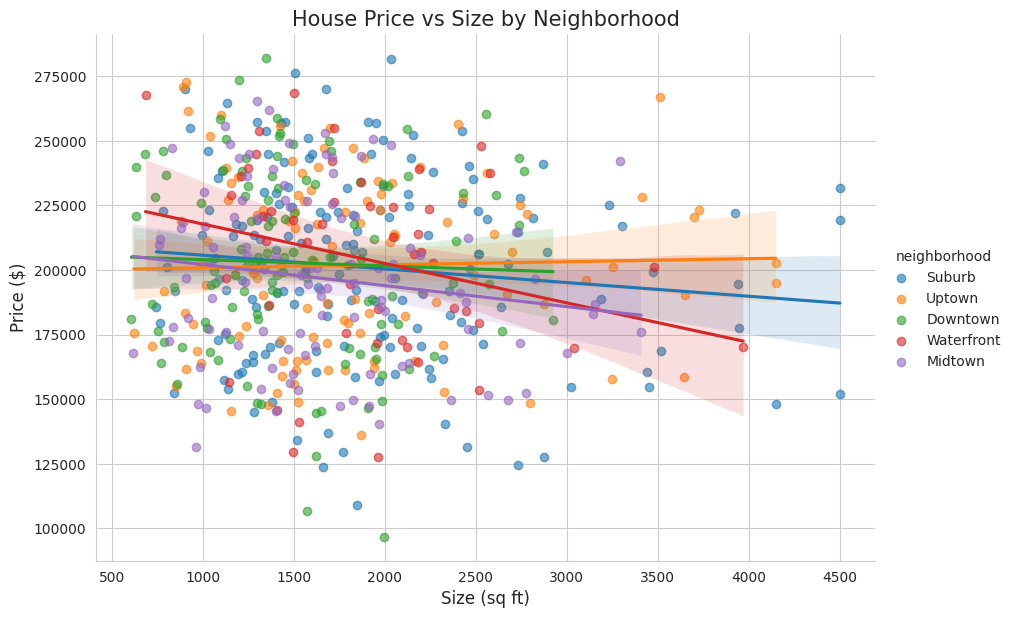

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
plt.figure(figsize=(10,6))

sns.lmplot( data=df, x='size', y='price', hue='neighborhood',
    height=6, aspect=1.5, scatter_kws={'alpha':0.6})

plt.title("House Price vs Size by Neighborhood", fontsize=15)
plt.xlabel("Size (sq ft)", fontsize=12)
plt.ylabel("Price ($)", fontsize=12)

plt.show()

The regression lines show how house price changes with size for each neighborhood . Visually the points are widely scattered, and the lines are relatively flat, which matches with the regression results where size and had a small or even negative effect and neighborhood differences were not significant. The plot makes it easy to see that size lone do not predict price. This visualizzation helps anticipate the low Rsquare from the model, In conclusion, combining size, price, and neighborhood in one figure gives a clear weak relation in the data.